In [37]:
import os
import pickle
import sys

import copy
import h5py
from deltaf import findBaselineF0

import scipy.io as sio
import autograd.numpy as np
import autograd.numpy.random as npr
npr.seed(12345)
from sklearn.decomposition import FactorAnalysis, PCA

import matplotlib.pyplot as plt

from statsmodels.tsa.api import SimpleExpSmoothing

In [38]:
mouse = "M2"
activity = "drink"
idx = 0

if mouse in ["M1", "M2"]:
    filepath = 'data/Refined_eat_drink_social_forNK.mat'
    raw = sio.loadmat(filepath)
    trial_data = np.einsum('nti -> itn', raw[f"{mouse}_{activity}"])
else:
    filepath = 'data/june1_processed_data_no_social.h5'
    with h5py.File(filepath, 'r') as f:
        trial_data = np.einsum('nti -> itn', f[mouse][activity][:])

In [39]:
def normalise_data(data):
    data = (data - data.mean(0)) / data.std(0)
    return data

def baseline_subtract_data(data, Fs=10):
    baseline = findBaselineF0(data, Fs, axis=1, keepdims=True)
    baseline_subtract_data = data - baseline
    return baseline_subtract_data

## Visualise raw neural data

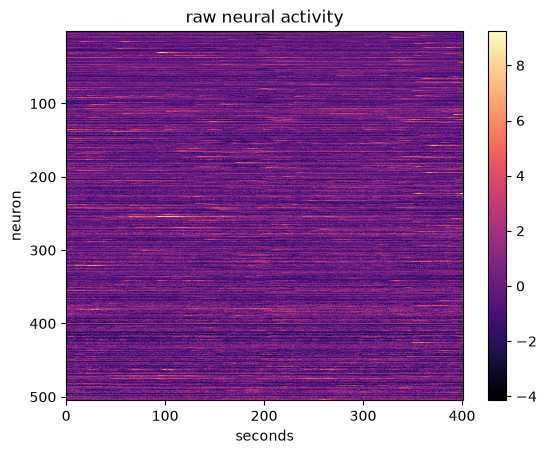

In [40]:
fig, ax = plt.subplots()

im = ax.imshow(
    trial_data[idx].T,
    aspect='auto',
    extent=[0, 401, trial_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('raw neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

In [41]:
norm_data = normalise_data(trial_data)

In [42]:
norm_data.shape

(17, 401, 505)

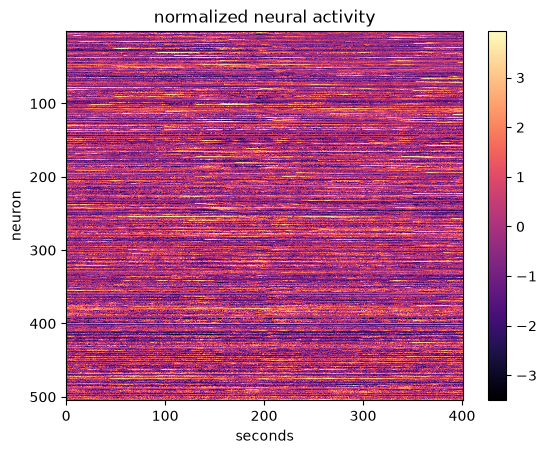

In [43]:
fig, ax = plt.subplots()

im = ax.imshow(
    norm_data[idx].T,
    aspect='auto',
    extent=[0, 401, norm_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('normalized neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

In [44]:
baseline_subtracted_data = baseline_subtract_data(trial_data, Fs=10)

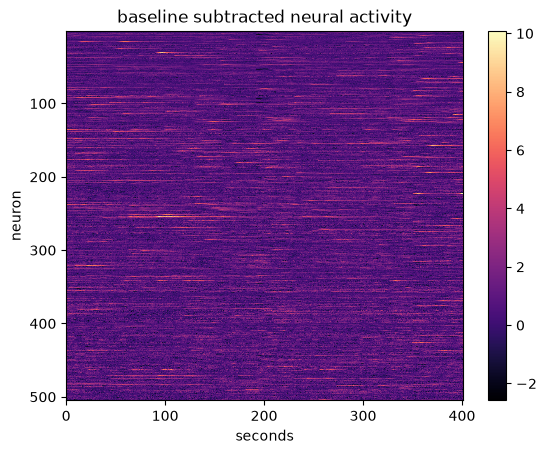

In [45]:
fig, ax = plt.subplots()

im = ax.imshow(
    baseline_subtracted_data[idx].T,
    aspect='auto',
    extent=[0, 401, baseline_subtracted_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('baseline subtracted neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

In [46]:
normalised_baseline_subtracted_data = baseline_subtract_data(norm_data, Fs=10)

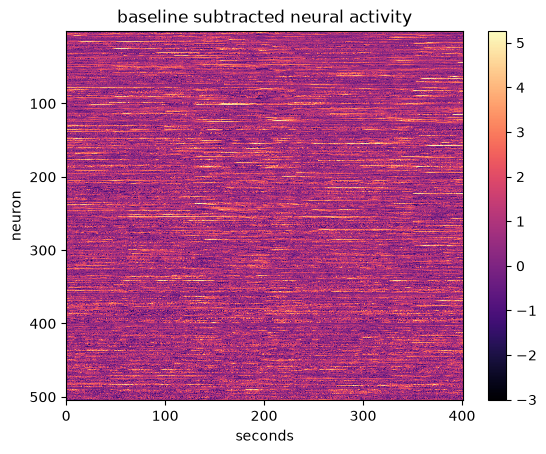

In [47]:
fig, ax = plt.subplots()

im = ax.imshow(
    normalised_baseline_subtracted_data[idx].T,
    aspect='auto',
    extent=[0, 401, normalised_baseline_subtracted_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('baseline subtracted neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

In [48]:
trial_data.shape

(17, 401, 505)

In [49]:
smoothed_data = []
for trial in trial_data:

    smooth_trial = []
    for neuron in trial.T:
        fit = SimpleExpSmoothing(neuron, initialization_method="heuristic").fit(smoothing_level=0.8, optimized=False)
        smooth_trial.append(fit.fittedvalues)
    smooth_trial = np.array(smooth_trial)
    smoothed_data.append(smooth_trial.T)
smoothed_data = np.array(smoothed_data)

smoothed_data.shape

(17, 401, 505)

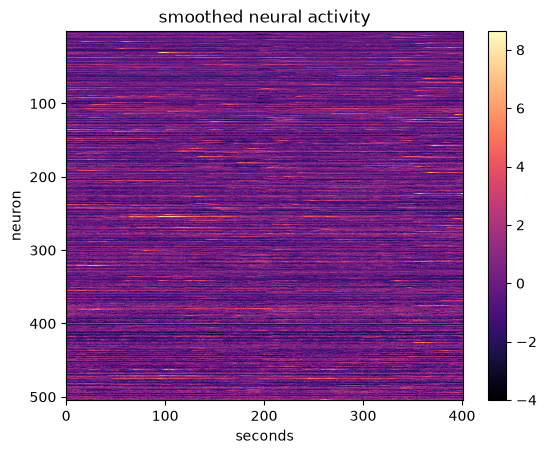

In [50]:
fig, ax = plt.subplots()

im = ax.imshow(
    smoothed_data[idx].T,
    aspect='auto',
    extent=[0, 401, smoothed_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('smoothed neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

## PCA

In [51]:
def train_pca(data, n_components = 10,start=0,end=400):
    data2pca = data
    data2pca_flat = data2pca.reshape(-1, data2pca.shape[-1])  # trials x time x neurons -> (trials*time) x neurons
    # fit PCA
    pca = PCA(n_components=n_components)
    pca.fit(data2pca_flat)
    return pca

def apply_pca(pca, data):
    data2pca = data
    data2pca_flat = data2pca.reshape(-1, data2pca.shape[-1])  # trials x time x neurons -> (trials*time) x neurons
    # apply PCA
    pca_results = pca.transform(data2pca_flat)
    pca_results = pca_results.reshape(data2pca.shape[0], data2pca.shape[1], -1)  # reshape back to trials x time x components
    return pca_results

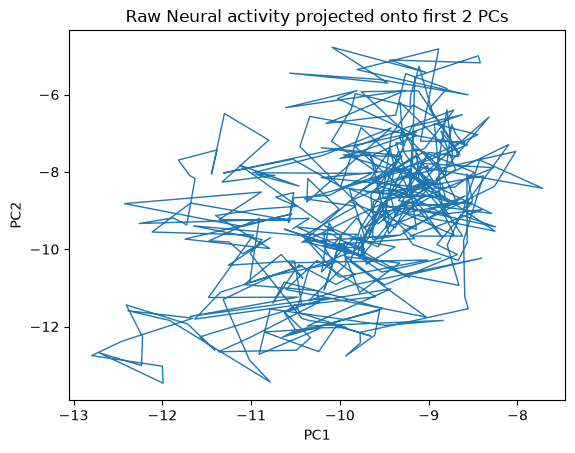

In [52]:
neural_pca = train_pca(trial_data, n_components=2)
pca_result = apply_pca(neural_pca, trial_data)

fig, ax = plt.subplots()
ax.plot(pca_result[idx, :, 0], pca_result[0, :, 1], lw=1)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Raw Neural activity projected onto first 2 PCs')

ax.tick_params(axis='both', which='major')

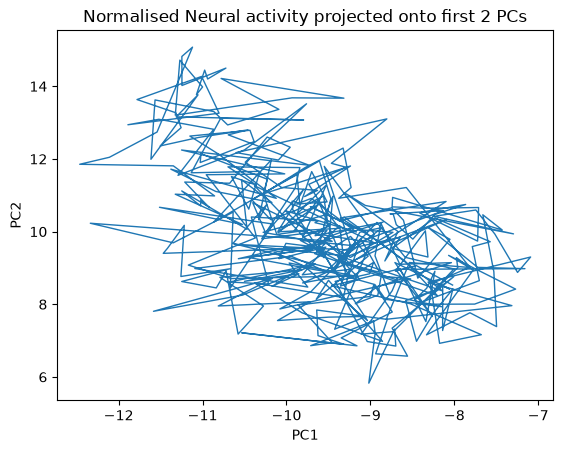

In [53]:
neural_pca = train_pca(norm_data, n_components=2)
pca_result = apply_pca(neural_pca, norm_data)

fig, ax = plt.subplots()
ax.plot(pca_result[idx, :, 0], pca_result[0, :, 1], lw=1)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Normalised Neural activity projected onto first 2 PCs')

ax.tick_params(axis='both', which='major')

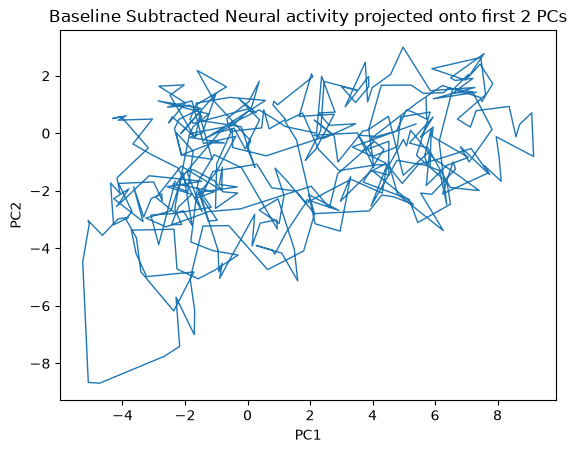

In [54]:
neural_pca = train_pca(baseline_subtracted_data, n_components=2)
pca_result = apply_pca(neural_pca, baseline_subtracted_data)

fig, ax = plt.subplots()
ax.plot(pca_result[idx, :, 0], pca_result[0, :, 1], lw=1)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Baseline Subtracted Neural activity projected onto first 2 PCs')

ax.tick_params(axis='both', which='major')

## 4000 timesteps

In [55]:
import pandas as pd

m2_data = pd.read_csv(f"./data/raw/M2_activity.csv", header=None)

In [56]:
m2_data

,0,1,2,3,4,5,6,7,8,9,...,35799,35800,35801,35802,35803,35804,35805,35806,35807,35808
0,0.245770,0.245770,0.245770,0.245770,0.15745,0.38303,0.24497,0.012017,-0.126340,0.168180,...,-0.475310,-0.840060,-0.705630,-0.67420,-0.616900,-0.804780,-0.76061,-1.010300,-0.98106,-0.66571
1,0.104730,0.104730,0.104730,0.104730,-0.13878,-0.13113,-0.28401,-0.026228,-0.106310,-0.053265,...,-0.307970,-0.229560,-0.251920,-0.35912,-0.171210,-0.028996,-0.25512,-0.374400,-0.34079,-0.16943
2,-1.119200,-1.119200,-1.119200,-1.119200,-1.09560,-0.57132,-0.49447,-0.365920,-0.667330,-0.368240,...,-0.263790,-0.153140,-0.477300,-0.43428,-0.351610,-0.546650,-0.35122,-0.425140,-0.63526,-0.54454
3,1.539500,1.539500,1.539500,1.539500,0.84777,0.99357,1.31340,0.514910,0.803320,1.793100,...,0.106750,0.288640,0.057964,0.65828,0.627940,0.254180,0.17006,0.284560,-0.35824,0.55034
4,-0.297460,-0.297460,-0.297460,-0.297460,-0.23705,-0.94954,-1.25660,-1.472800,-1.564000,-1.374400,...,-0.414920,-0.226980,-0.386730,-0.36659,-0.380350,-0.376660,-0.67166,-0.761270,-0.71025,-0.74684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,0.089813,0.089813,0.089813,0.089813,-0.15047,-0.40255,1.09810,-0.182750,0.489720,0.100880,...,0.808830,-0.300540,0.429110,-0.14061,0.050249,0.676270,-0.86021,0.029509,0.36824,0.10051
501,1.334600,1.334600,1.334600,1.334600,1.29310,-0.19293,0.77597,0.292230,1.078800,2.111600,...,-0.533570,0.332620,0.310150,0.31791,-0.544280,-0.878790,0.91039,-0.312230,-0.25482,-0.72386
502,-0.243930,-0.243930,-0.243930,-0.243930,0.22545,1.67360,0.33416,0.631190,0.069362,0.406200,...,0.228380,-0.014290,0.392130,1.37680,0.522200,0.524290,0.59473,0.868080,-0.38487,-1.44200
503,-0.010315,-0.010315,-0.010315,-0.010315,1.48700,0.75490,1.01100,1.601800,0.745990,1.592600,...,-1.640800,-2.355200,-1.469200,-1.48630,-1.779900,-1.294200,-1.95670,-1.219100,-2.48650,-2.86680


In [57]:
start_frames = pd.read_csv("./data/raw/M2_eat3_start_frames.csv", header=None)

In [58]:
filepath = 'data/Refined_eat_drink_social_forNK.mat'
raw = sio.loadmat(filepath)
raw[f"M2_eat3_pel"]

array([[(array([[100, 135, 171]], dtype=uint8),),
        (array([[100, 143, 187]], dtype=uint8),),
        (array([[100, 119, 227]], dtype=uint8),),
        (array([[100, 140, 175]], dtype=uint8),),
        (array([[100, 119, 146]], dtype=uint8),),
        (array([[100, 162, 255]], dtype=uint8),),
        (array([[100, 156, 202]], dtype=uint8),),
        (array([[100, 140, 160]], dtype=uint8),),
        (array([[100, 155, 192]], dtype=uint8),),
        (array([[100, 162, 195]], dtype=uint8),),
        (array([[100, 141, 155]], dtype=uint8),)]],
      dtype=[('pellet_retrievals', 'O')])

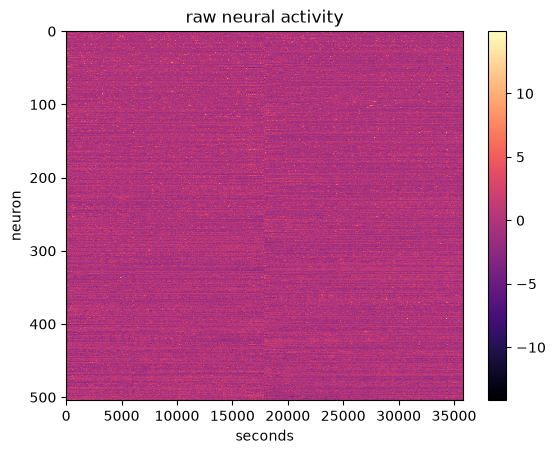

In [59]:
fig, ax = plt.subplots()

im = ax.imshow(
    m2_data,
    aspect='auto',
    # extent=[0, 401, norm_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

# ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('raw neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

In [60]:
print(start_frames.iloc[:, 0])

0      110900.0
1      667830.0
2      807640.0
3      901690.0
4      950340.0
5     1002200.0
6     1929600.0
7     1980700.0
8     2437500.0
9     3419500.0
10    3575000.0
Name: 0, dtype: float64


In [61]:
m2_data.shape[1]

35809

In [62]:
example_frame = start_frames.iloc[2, 0]

m2_trial_1 = m2_data.iloc[:, max(0, int(example_frame // 100) - 1000):min(m2_data.shape[1], int(example_frame // 100) + 3200)]

In [63]:
m2_trials = []

for start_frame in start_frames.iloc[:, 0]:
    to_add = m2_data.iloc[:, max(0, int(start_frame // 100) - 1000):min(m2_data.shape[1], int(start_frame // 100) + 3200)].to_numpy()
    m2_trials.append(np.resize(to_add, (505, 4200)))

m2_trials = np.array(m2_trials)

In [64]:
m2_trials

array([[[-0.40538  , -0.28587  , -0.34489  , ..., -0.051501 ,
         -0.16217  ,  0.081437 ],
        [-0.44169  , -0.25866  , -0.072212 , ..., -0.14923  ,
         -0.091831 , -0.53521  ],
        [ 0.023057 , -0.042354 , -0.17039  , ..., -0.78277  ,
         -0.6929   , -0.73085  ],
        ...,
        [ 1.065    ,  0.12059  , -0.036459 , ...,  0.78988  ,
          1.9141   ,  1.1447   ],
        [ 0.43667  ,  1.1372   ,  0.51554  , ...,  0.63093  ,
          0.6683   ,  0.56551  ],
        [ 0.99316  ,  0.37289  , -0.98335  , ..., -0.89081  ,
         -0.79905  , -0.50638  ]],

       [[ 0.56346  ,  0.25146  ,  0.32734  , ...,  0.044378 ,
         -0.0082655,  0.11029  ],
        [-0.41289  , -0.31859  , -0.77209  , ..., -0.40689  ,
         -0.46147  , -0.75201  ],
        [-0.53539  , -0.82493  , -0.43447  , ..., -0.24215  ,
         -0.45606  , -0.59742  ],
        ...,
        [ 0.22062  ,  0.60317  , -0.060988 , ...,  1.3467   ,
          0.77023  ,  0.78109  ],
        [ 1.

In [65]:
import h5py

rearranged_trials = np.einsum('int -> nti', m2_trials)

with h5py.File(f"data/M2_eat3long.h5", 'w') as f:
    mouse_group = f.create_group('M2')
    mouse_group.create_dataset('eat3long', data=rearranged_trials, compression='gzip', compression_opts=4)

In [66]:
m2_trials_short = []

for start_frame in start_frames.iloc[:, 0]:
    to_add = m2_data.iloc[:, max(0, int(start_frame // 100) - 100):min(m2_data.shape[1], int(start_frame // 100) + 301)].to_numpy()
    m2_trials_short.append(np.resize(to_add, (505, 401)))

m2_trials_short = np.array(m2_trials_short)

In [67]:
import h5py

rearranged_trials = np.einsum('int -> nti', m2_trials_short)

with h5py.File(f"data/M2_eat3.h5", 'w') as f:
    mouse_group = f.create_group('M2')
    mouse_group.create_dataset('eat3', data=rearranged_trials, compression='gzip', compression_opts=4)

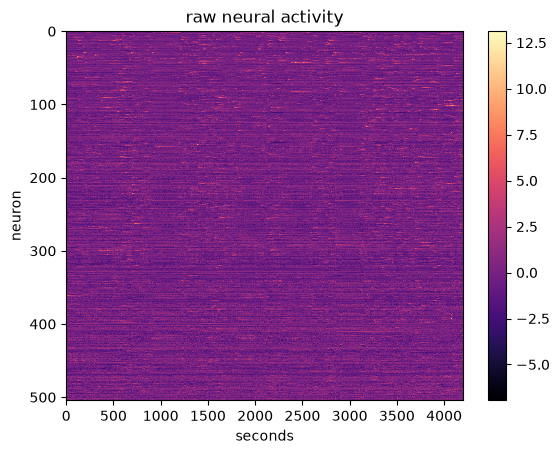

In [68]:
fig, ax = plt.subplots()

im = ax.imshow(
    m2_trial_1,
    aspect='auto',
    # extent=[0, 401, norm_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

# ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('raw neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

In [69]:
m2_trial_1_sb = baseline_subtract_data(m2_trial_1, Fs=10)

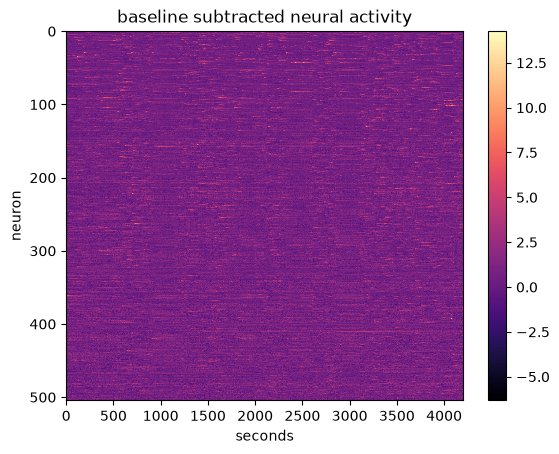

In [70]:
fig, ax = plt.subplots()

im = ax.imshow(
    m2_trial_1_sb,
    aspect='auto',
    # extent=[0, 401, norm_data.shape[2], 1],
    interpolation='none',
    cmap='magma'
)

# ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('baseline subtracted neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)

In [71]:
m2_trial_1_nrm = normalise_data(m2_trial_1)

/var/folders/ly/x3ygxn9x7n3__2s9dmdz310c0000gn/T/ipykernel_1688/2323613626.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  data = (data - data.mean(0)) / data.std(0)
/var/folders/ly/x3ygxn9x7n3__2s9dmdz310c0000gn/T/ipykernel_1688/2323613626.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  data = (data - data.mean(0)) / data.std(0)


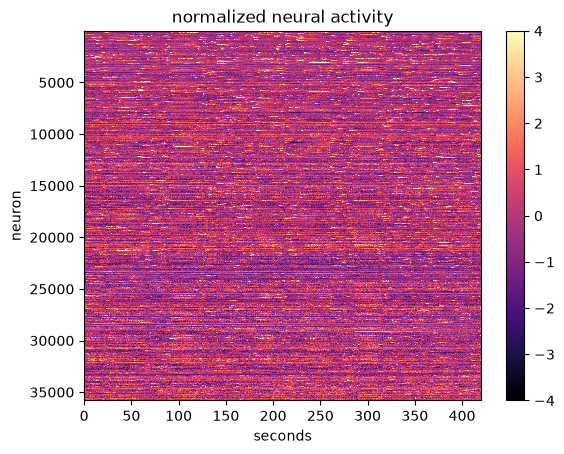

In [72]:
fig, ax = plt.subplots()

im = ax.imshow(
    m2_trial_1_nrm,
    aspect='auto',
    extent=[0, 420, m2_data.shape[1], 1],
    interpolation='none',
    vmin=-4,
    vmax=4,
    cmap='magma'
)

# ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds',)     # set xlabel font size
ax.set_ylabel('neuron',)      # set ylabel font size
ax.set_title('normalized neural activity',)  # set title font size

ax.tick_params(axis='both', which='major',)  # set tick label size

fig.colorbar(im, ax=ax)